<a href="https://colab.research.google.com/github/olawaleaboderin/AVCAD/blob/main/Ex10_Interactive_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ── Load dataset ─────────────────────────────────────────────
df = pd.read_csv(
    'https://raw.githubusercontent.com/olawaleaboderin/greends-avcad-2026/main/examples/EFIplus_medit.zip',
    sep=";"
)


**Preprocessing Stage**

In [3]:
# ── Environmental variables ───────────────────────────────────
predictors = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch',
              'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']

# ── Filter: Douro, Tejo, Mondego and Minho basins ────────────
basins    = ['Douro', 'Tejo', 'Mondego', 'Minho']
df_basins = df[df['Catchment_name'].isin(basins)].copy()

# ── Select predictors and drop NAs ───────────────────────────
df_clean = df_basins[predictors + ['Catchment_name', 'Site_code']].dropna()
X        = df_clean[predictors].values
y        = df_clean['Catchment_name'].values

print(f"Dataset: {X.shape[0]} sites × {X.shape[1]} variables")
print("Sites per basin:")
print(df_clean['Catchment_name'].value_counts())

# ── Standardise ───────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Colour palette
palette = {'Douro': 'steelblue', 'Tejo': 'coral',
           'Mondego': 'seagreen', 'Minho': 'mediumpurple'}


Dataset: 1681 sites × 7 variables
Sites per basin:
Catchment_name
Minho      707
Tejo       493
Douro      395
Mondego     86
Name: count, dtype: int64


# Question 1: Run a Linear Discriminant Analysis based on quantitative environmental variables (see previousexercises), using the Douro, Tejo, Mondego and Minho basins as the pre-determined groups. Produce a biplot with ‘Catchment_name’ as a grouping variable.

**AI Prompt:** *Run a Linear Discriminant Analysis on the seven standardised quantitative environmental variables (Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul) using Catchment_name as the grouping variable. Produce a static biplot projecting sites onto LD1 and LD2, coloured by basin, with group centroids marked as stars and arrows showing variable contributions using LDA scalings. Report explained variance per discriminant axis, print a classification report, confusion matrix and LDA loadings table.*




EXERCISE 1 — LDA + Static Biplot

Explained variance by discriminant functions:
  LD1: 90.62%  (cumulative: 90.62%)
  LD2: 5.73%  (cumulative: 96.35%)
  LD3: 3.65%  (cumulative: 100.00%)

Cross-validated classification accuracy:
  Mean Accuracy = 0.798
  Standard Deviation = 0.044

Classification Report:
              precision    recall  f1-score   support

       Douro       0.72      0.61      0.66       395
       Minho       0.87      0.97      0.92       707
     Mondego       0.70      0.66      0.68        86
        Tejo       0.89      0.86      0.87       493

    accuracy                           0.84      1681
   macro avg       0.79      0.78      0.78      1681
weighted avg       0.83      0.84      0.83      1681


Confusion Matrix:
         Douro  Tejo  Mondego  Minho
Douro      241    49        6     99
Tejo        51   423       18      1
Mondego     24     4       57      1
Minho       17     0        1    689

LDA Loadings:
                            LD1     LD2

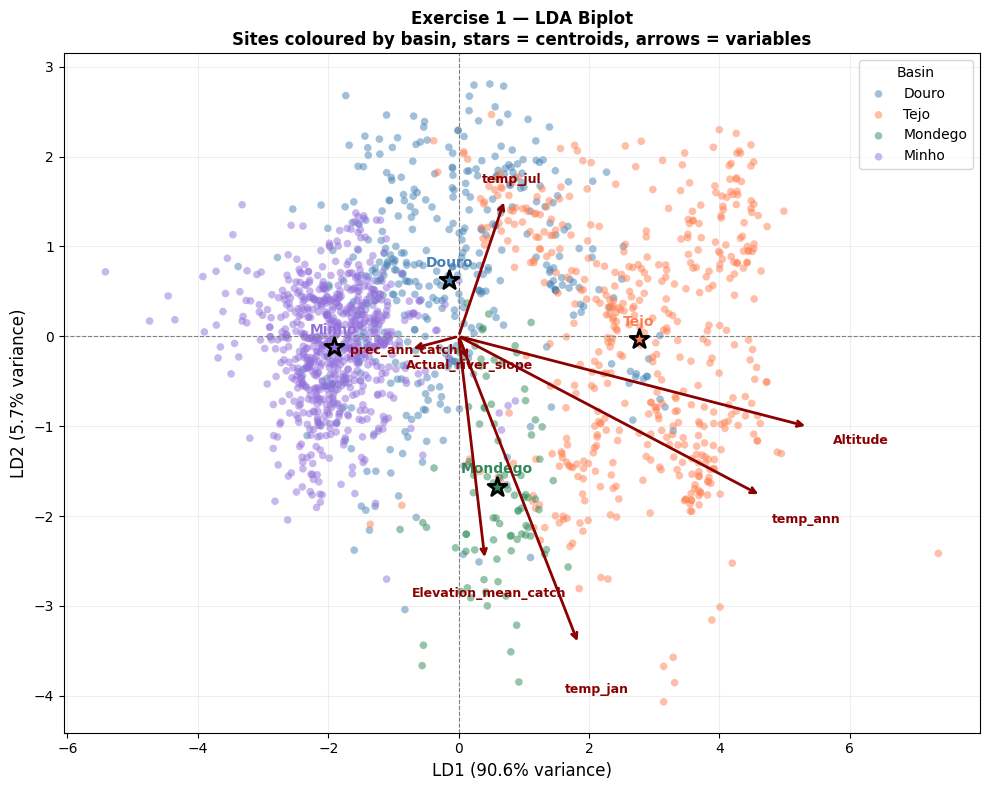

In [4]:

print("\n" + "="*60)
print("EXERCISE 1 — LDA + Static Biplot")
print("="*60)

lda     = LDA()
X_lda   = lda.fit_transform(X_scaled, y)

exp_var_lda = lda.explained_variance_ratio_ * 100
print("\nExplained variance by discriminant functions:")
for i, ev in enumerate(exp_var_lda):
    print(f"  LD{i+1}: {ev:.2f}%  (cumulative: {sum(exp_var_lda[:i+1]):.2f}%)")

# Cross-validated accuracy
cv_scores = cross_val_score(LDA(), X_scaled, y, cv=5)
print(f"\nCross-validated classification accuracy:")
print(f"  Mean Accuracy = {cv_scores.mean():.3f}")
print(f"  Standard Deviation = {cv_scores.std():.3f}")

# Classification report
y_pred = lda.predict(X_scaled)
print("\nClassification Report:")
print(classification_report(y, y_pred))

print("\nConfusion Matrix:")
cm = pd.DataFrame(
    confusion_matrix(y, y_pred, labels=basins),
    index=basins, columns=basins
)
print(cm)

# LDA loadings
loadings_lda = pd.DataFrame(
    lda.scalings_,
    index=predictors,
    columns=[f'LD{i+1}' for i in range(lda.scalings_.shape[1])]
).round(3)
exp_var_row  = pd.DataFrame([exp_var_lda],
                             columns=[f'LD{i+1}' for i in range(len(exp_var_lda))],
                             index=['Explained Variance (%)'])
cum_var_row  = pd.DataFrame([np.cumsum(exp_var_lda)],
                             columns=[f'LD{i+1}' for i in range(len(exp_var_lda))],
                             index=['Cumulative Variance (%)'])
print("\nLDA Loadings:")
print(pd.concat([loadings_lda, exp_var_row, cum_var_row]).round(3))

# ── Static biplot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

for basin in basins:
    mask = y == basin
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
               color=palette[basin], label=basin,
               alpha=0.5, s=30, edgecolors='none')

# Group centroids
for basin in basins:
    mask = y == basin
    cx, cy = X_lda[mask, 0].mean(), X_lda[mask, 1].mean()
    ax.scatter(cx, cy, color=palette[basin], s=200,
               edgecolors='black', linewidths=2,
               marker='*', zorder=5)
    ax.text(cx, cy + 0.15, basin, fontsize=10,
            fontweight='bold', color=palette[basin], ha='center')

# Variable arrows
scale    = 1.5
scalings = lda.scalings_
for j, var in enumerate(predictors):
    ax.annotate('',
                xy=(scalings[j, 0] * scale, scalings[j, 1] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=2))
    ax.text(scalings[j, 0] * scale * 1.15,
            scalings[j, 1] * scale * 1.15,
            var, color='darkred', fontsize=9,
            fontweight='bold', ha='center', va='center')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel(f'LD1 ({exp_var_lda[0]:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'LD2 ({exp_var_lda[1]:.1f}% variance)', fontsize=12)
ax.set_title('Exercise 1 — LDA Biplot\n'
             'Sites coloured by basin, stars = centroids, arrows = variables',
             fontsize=12, fontweight='bold')
ax.legend(title='Basin', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


The LDA successfully discriminated between the four river basins based on their environmental characteristics. LD1 alone explains 90.6% of the between-group variance, with Altitude (3.573) and temp_ann (3.091) as the strongest discriminators, confirming that the primary environmental gradient separating the basins is a combined temperature-altitude axis. Tejo sites score highest on LD1, reflecting their warmer and lower-altitude character, while Minho sites score lowest, reflecting cooler and wetter conditions. LD2 explains a further 5.7%, driven by Elevation_mean_catch (-1.658) and temp_jan (-2.281), separating Mondego from the other basins along a seasonal thermal gradient. The overall classification accuracy of 84% confirms that environmental variables are strong predictors of basin identity. The cross-validated accuracy of 79.8% is slightly lower than the training accuracy, indicating a small degree of overfitting, though the model still generalises reasonably well. The confusion matrix shows that misclassification is most common between Douro and Minho (99 Douro sites predicted as Minho) and between Mondego and Douro (24 cases), reflecting genuine environmental overlap between these neighbouring basins.

##Question 2: Try to build interactive plots that display data in the space defined by the Discriminant Functions.

**AI Prompt:** *Using the LDA results from Exercise 1, build three interactive plots using Plotly. First, an interactive biplot of LD1 vs LD2 with sites coloured by basin, variable arrows overlaid, group centroids marked as stars, and hover functionality showing site code and environmental variable values. Second, an interactive plot highlighting correctly classified sites as circles and misclassified sites as X markers. Third, a 3D interactive scatter plot using LD1, LD2 and LD3, coloured by basin, allowing rotation and zoom to explore the full discriminant space.*

In [5]:

print("\n" + "="*60)
print("EXERCISE 2 — Interactive Plots")
print("="*60)

# Build dataframe with LDA scores for plotting
lda_df = pd.DataFrame(X_lda,
                       columns=[f'LD{i+1}' for i in range(X_lda.shape[1])])
lda_df['Basin']     = y
lda_df['Site_code'] = df_clean['Site_code'].values
lda_df['Predicted'] = y_pred
lda_df['Correct']   = lda_df['Basin'] == lda_df['Predicted']

# Add original environmental variable values for hover info
for pred in predictors:
    lda_df[pred] = df_clean[pred].values

# ── Plot 1: Interactive biplot (LD1 vs LD2) ──────────────────
fig1 = px.scatter(
    lda_df,
    x='LD1', y='LD2',
    color='Basin',
    color_discrete_map=palette,
    hover_data=['Site_code'] + predictors,
    title='Exercise 2 — Interactive LDA Biplot (LD1 vs LD2)<br>'
          '<sup>Hover over points to see site details</sup>',
    labels={
        'LD1': f'LD1 ({exp_var_lda[0]:.1f}% variance)',
        'LD2': f'LD2 ({exp_var_lda[1]:.1f}% variance)'
    },
    opacity=0.6,
    template='plotly_white'
)

# Add variable arrows as annotations
for j, var in enumerate(predictors):
    scale = 1.5
    fig1.add_annotation(
        x=scalings[j, 0] * scale,
        y=scalings[j, 1] * scale,
        ax=0, ay=0,
        xref='x', yref='y',
        axref='x', ayref='y',
        text=var,
        showarrow=True,
        arrowhead=2,
        arrowcolor='darkred',
        arrowwidth=2,
        font=dict(color='darkred', size=10)
    )

# Add centroids
for basin in basins:
    mask = lda_df['Basin'] == basin
    cx   = lda_df.loc[mask, 'LD1'].mean()
    cy   = lda_df.loc[mask, 'LD2'].mean()
    fig1.add_trace(go.Scatter(
        x=[cx], y=[cy],
        mode='markers+text',
        marker=dict(symbol='star', size=18,
                    color=palette[basin],
                    line=dict(color='black', width=1.5)),
        text=[basin],
        textposition='top center',
        textfont=dict(size=11, color=palette[basin]),
        showlegend=False,
        hoverinfo='skip'
    ))

fig1.update_layout(
    width=900, height=650,
    legend_title_text='Basin'
)
fig1.show()




EXERCISE 2 — Interactive Plots


In [6]:
# ── Plot 2: Interactive plot highlighting misclassified sites ─
fig2 = px.scatter(
    lda_df,
    x='LD1', y='LD2',
    color='Basin',
    color_discrete_map=palette,
    symbol='Correct',
    symbol_map={True: 'circle', False: 'x'},
    hover_data=['Site_code', 'Predicted'] + predictors,
    title='Exercise 2 — Interactive LDA: Correct vs Misclassified sites<br>'
          '<sup>Circle = correctly classified | X = misclassified</sup>',
    labels={
        'LD1': f'LD1 ({exp_var_lda[0]:.1f}% variance)',
        'LD2': f'LD2 ({exp_var_lda[1]:.1f}% variance)'
    },
    opacity=0.6,
    template='plotly_white'
)
fig2.update_layout(width=900, height=650)
fig2.show()



In [7]:
# ── Plot 3: 3D interactive plot (LD1, LD2, LD3) ──────────────
# Only if 3 discriminant functions exist
if X_lda.shape[1] >= 3:
    fig3 = px.scatter_3d(
        lda_df,
        x='LD1', y='LD2', z='LD3',
        color='Basin',
        color_discrete_map=palette,
        hover_data=['Site_code'] + predictors,
        title='Exercise 2 — Interactive 3D LDA Plot (LD1, LD2, LD3)',
        opacity=0.5,
        template='plotly_white'
    )
    fig3.update_layout(width=900, height=700)
    fig3.show()
else:
    print("Only 2 discriminant axes available — 3D plot skipped.")

The interactive plots add significant value over the static biplot by allowing direct exploration of individual sites in discriminant space. The first interactive biplot (LD1 vs LD2) replicates the static version but enables hovering over any point to retrieve the site code and its exact environmental variable values, making it easy to identify which specific sites drive the overlap between basins. The second plot, highlighting correctly classified versus misclassified sites, reveals that misclassified points are not randomly distributed, they are concentrated in the overlap zones between basin clusters, particularly in the central region of the plot where Douro, Mondego and Tejo sites intermingle. This confirms that misclassification is driven by genuine environmental similarity rather than model failure. The 3D interactive plot using all three discriminant axes provides additional separation, particularly for Minho sites which form a tight and well-separated cluster in the upper region of the 3D space, while Tejo sites remain spread across the lower portion. The ability to rotate the 3D plot reveals that some sites which appear to overlap in the 2D projection are actually well-separated when the third axis is included, demonstrating the added value of interactive visualisation for interpreting multivariate ordination results.